# PROGRAMMING FROM ZERO: AI-ASSISTED PROGRAMMING FOR RESEARCH

# Introduction

## Narrative


1. 1st year grad student. Paper to analyze: The source is "'I disrepsectfully agree.' The Differential Effects of  Partisan Sorting on Behavioral and Issue Polarization", L Mason, 2014.
2. Learning objectives
3. Narrative is a possible analysis workflow, but not advocating that this is effective in all circumstances.
4. ANES data is edited to fit in github.

## Evolution of Human-Computer Interactions

<img src="https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/docs/images/programming_history.png"
         alt="Types of feature extractiom."
         width="5000">

Theme: Creating programs that can be *read* by humans.

Shortcoming: Special training is required to *write* programs.

<img src="https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/docs/images/ai_assisted_programming.png"
         alt="Types of feature extractiom."
         width="5000">

## Learning Objectives

1. Students will be able to list the descriptions and scales of variables in the ANES data that are relevant for their analysis.
1. Students will be able to compose LLM prompts for:
    1. creating a pandas DataFrame containing variables of interest with descriptive column names for the variables;
    1. obtaining desired subsets of a DataFrame;
    1. constructing contingency tables to relate categorical data;
    1. plotting categorical data as grouped bar plots.
1. Students can explain the following strategies for testing code produced by an LLM
    1. comparing with a known result
    1. comparing two results with a known relationship
    1. handling “corner cases”
1. Students can explain when and how to apply the following approaches to improving their prompts:
   1. provide more detail
    1. add examples
    1. state what *not* to do
1. Students will be able to explain the importance of the following with regard to LLM interactions: (a) how to preserve prompts; (b) how to properly identify the results of a series of LLM interactions; and (c) how to ensure that the notebook can be run by others.


# Python for Data Analysis

## What is Python

* Python is a procedural computer language intended to be human readable (but not necessarily human writeable).

* Python has a core, and it has many add-ons called libraries. To include a library in your program, you use an ``import`` statement. Libraries are used to read data, do statistical analysis and do plotting.

* All elements of Python are objects. Objects may contain both data and executable code. The components of an object are called attributes and are accessed using the dot (".") operator. Names in Python are case sensitive.

## Simple Python

In [ ]:
# Setting values and added them
var1 = 1
var2 = 2
print(var1 + var2)

3


In [ ]:
# Check if a string has a list of words

# Create a string by using double or single quotes
a_string = "The quick brown fox jumps over the lazy dog"

# Create a list of words to find
words = ["dog", "fox", "bear"]

# Search for each word in the string by using 'for' to iterate and 'if' to test
for word in words:
    if word in a_string:
        print(f"Found {word}!")


Found dog!
Found fox!


Functions provide a way to create your own library of useful data and code.

A function using specified using ``def``. You provide a function name, its inputs (arguments),
and use a ``return`` statement to return results.

In [ ]:
# You can make code reusable by defining a function
def searchString(search_string:str, search_words:list)->list:
    results = []
    for word in search_words:
        if word in search_string:
            results.append(word)
    return results

# Run the function
a_string = "The quick brown fox jumps over the lazy dog"
words = ["dog", "fox", "bear"]
searchString(a_string, words)

['dog', 'fox']

## DataFrames

A DataFrame is a python representation of a table.

* A table has columns of the same length (and type). Columns have names.
* A table has rows, each of which contains a value for all columns.
* You can select subsets of rows and columns based on the values in the table.

In [ ]:
# An example
import pandas as pd

household_df = pd.DataFrame({
    'family': ['adams', 'johnson', 'smith'],
    'pets': ['yes', 'no', 'maybe'],
    'num_children': [2, 0, 10],
    'num_occupant': [4, 2, 11],
}
)
household_df

,family,pets,num_children,num_occupant
0,adams,yes,2,4
1,johnson,no,0,2
2,smith,maybe,10,11


In [ ]:
# Names of the families
household_df['family']

,family
0,adams
1,johnson
2,smith


In [ ]:
# Can use a variable instead of a string
family_column = 'family'
household_df[family_column]

,family
0,adams
1,johnson
2,smith


In [ ]:
# Can do operations on columns (and rows)

In [ ]:
# How many adjults are there in the households? Add an 'num_adult' column
household_df['num_adult'] = household_df['num_occupant'] - household_df['num_children']
household_df

,family,pets,num_children,num_occupant,num_adult
0,adams,yes,2,4,2
1,johnson,no,0,2,2
2,smith,maybe,10,11,1


In [ ]:
# Select the families who have children
selector = household_df['num_children'] > 0
household_df[selector]

,family,pets,num_children,num_occupant,num_adult
0,adams,yes,2,4,2
2,smith,maybe,10,11,1


## Python libraries used in this notebook

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Getting the data

We begin by writing python to read data in a comma-separated-variable (CSV) file.

Data are [here](https://github.com/joseph-hellerstein/programming_from_zero/blob/main/data/anes_timeseries_cdf_csv_20260205_bottom.csv) in the data directory.

## Interactions

**Prompt: Get the data**

Create python code that reads the CSV in the above URL into a dataframe called ANES_DF.

## Result

This section provides the final desired result, including some edits for names and other considerations.

In [ ]:
import pandas as pd

# The raw URL for the CSV file, as referenced in the text cell above.
URL = 'https://raw.githubusercontent.com/joseph-hellerstein/programming_from_zero/main/data/anes_timeseries_cdf_csv_20260205_bottom.csv'

ANES_DF = pd.read_csv(URL)
display(ANES_DF.head())

/tmp/ipython-input-532784942.py:6: DtypeWarning: Columns (4,5,6,7,8,9,13,14,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,38,42,43,45,47,48,49,51,53,60,62,63,65,66,67,68,69,70,72,73,74,76,77,79,80,81,82,83,84,89,90,91,95,96,97,98,99,100,101,104,105,106,107,108,109,113,116,117,118,120,121,122,126,127,128,129,130,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,150,151,152,154,157,158,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,233,254,275,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,318,323,328,330,331,332,333,334,335,336,337,338,339,340,361,382,403,424,425,426,427,428,430,431,433,434,435,436,437,438,439,447,448,449,450,451,452,453,454,458,459,460,462,463,467,468,469,470,473,474,475,476,478,484,485,489,490,491,498,499,500,504,505,506,507,510,511,513,514,515,524,525,526,5

,Version,VCF0004,VCF0006,VCF0006a,VCF0009x,VCF0010x,VCF0011x,VCF0009y,VCF0010y,VCF0011y,...,VCF9272,VCF9273,VCF9274,VCF9275,VCF9277,VCF9278,VCF9279,VCF9280,VCF9281,VCF9282
0,ANES_CDF_VERSION:2026-Feb-5,1986,563,19860563,1,1,1,1,1,1,...,,,,,-9,-9,,,,
1,ANES_CDF_VERSION:2026-Feb-5,1986,564,19860564,1,1,1,1,1,1,...,,,,,-9,-9,,,,
2,ANES_CDF_VERSION:2026-Feb-5,1986,565,19860565,1,1,1,1,1,1,...,,,,,-9,-9,,,,
3,ANES_CDF_VERSION:2026-Feb-5,1986,566,19860566,1,1,1,1,1,1,...,,,,,1,2,,,,
4,ANES_CDF_VERSION:2026-Feb-5,1986,567,19860567,1,1,1,1,1,1,...,,,,,3,-9,,,,


## What we learned

1. Gemini can handle some details that we might not consider.
1. Gemini can read the prompt in a cell.

# Selecting relevant variables

We are interested in
* partisanship
* geography
* time

For each, we want to know:
* Descrition
* Scale

## Interactions for variables

Prompt for variables: Please find the variables that most relate to partisanship, geograph, and time. Provide their descriptions and scales. Ignore other cells below in this notebook. Enter your response under the heading below titled "Result". The markdown you use should be at a lower level than "##".

**Prompt for selecting variables**

 I want to construct an analysis of how partisanship changes  by geography over time. Which variables do you suggest that I use?

**Response for selecting variables**

For Partisanship:

* VCF0301 - Party Identification (7-Point Scale): This is a core measure of party ID and provides a good range for analysis.
*VCF0305 - Strength of Partisanship: Useful for understanding the intensity of partisan attachment, which might vary geographically or over time.

For Geography:

*VCF0104 - Region: This provides a broad geographic categorization.

* VCF0101 - State FIPS Code: For a more granular geographic analysis, allowing you to group by individual states.

For Time:

* VCF0004 - Study Year: Essential for tracking changes across different survey waves and time periods.

**Prompt for updating dataframe**

 Please create a new dataframe that only contains the variables in the above list. Also, use more meaningful names for the columns in the dataframe.

In [ ]:
import pandas as pd

columns_to_select = {
    'VCF0301': 'party_identification',
    'VCF0305': 'partisanship_strength',
    'VCF0104': 'region',
    'VCF0101': 'state_fips_code',
    'VCF0004': 'study_year'
}

# Select the columns and rename them
DATA_DF = ANES_DF[list(columns_to_select.keys())].rename(columns=columns_to_select)

# Display the first few rows of the new DataFrame
display(DATA_DF.head())

,party_identification,partisanship_strength,region,state_fips_code,study_year
0,6,3,2,29,1986
1,0,1,2,50,1986
2,5,2,2,42,1986
3,7,4,2,27,1986
4,0,0,1,38,1986


**Prompt for refining dataframe**

 Many of the row in the above dataframe have missing values. Refine the above code so that rows with missing values are not included.

## Result

**Prompt: Package data creation**

Create a function that reads the data, selects the variables, names the columns, and deletes rows with missing data.

In [ ]:
import pandas as pd
import numpy as np

COLUMN_MAP = {
    'VCF0301': 'party_identification',
    'VCF0305': 'partisanship_strength',
    'VCF0104': 'region',
    'VCF0101': 'state_fips_code',
    'VCF0004': 'study_year'
}
def create_and_clean_dataframe(
        url=URL, column_map=COLUMN_MAP,
        ) -> pd.DataFrame:
    """
    Reads data from a URL, selects and renames columns, converts them to numeric,
    and removes rows with missing values.

    Args:
        url (str): The URL of the CSV file.
        column_map (dict): A dictionary mapping original column names to new column names.

    Returns:
        pd.DataFrame: A cleaned DataFrame with selected and renamed columns.
    """
    # Read the CSV data
    anes_df = pd.read_csv(url)

    # Select and rename columns
    selected_df = anes_df[list(column_map.keys())].rename(columns=column_map)

    # Convert columns to numeric, coercing errors to NaN
    for col in selected_df.columns:
        selected_df[col] = pd.to_numeric(selected_df[col], errors='coerce')

    # Drop rows with NaN values
    cleaned_df = selected_df.dropna()

    return cleaned_df

# Use the new function to create the DATA_DF
DATA_DF = create_and_clean_dataframe(URL, COLUMN_MAP)

print(f"Created DATA_DF with {DATA_DF.shape[0]} rows and {DATA_DF.shape[1]} columns.")
display(DATA_DF.head())

/tmp/ipython-input-3021136401.py:26: DtypeWarning: Columns (4,5,6,7,8,9,13,14,17,18,19,21,22,23,24,25,26,27,28,29,30,31,32,33,38,42,43,45,47,48,49,51,53,60,62,63,65,66,67,68,69,70,72,73,74,76,77,79,80,81,82,83,84,89,90,91,95,96,97,98,99,100,101,104,105,106,107,108,109,113,116,117,118,120,121,122,126,127,128,129,130,131,132,133,135,136,137,138,139,140,141,142,143,144,145,146,147,150,151,152,154,157,158,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,233,254,275,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,318,323,328,330,331,332,333,334,335,336,337,338,339,340,361,382,403,424,425,426,427,428,430,431,433,434,435,436,437,438,439,447,448,449,450,451,452,453,454,458,459,460,462,463,467,468,469,470,473,474,475,476,478,484,485,489,490,491,498,499,500,504,505,506,507,510,511,513,514,515,524,525,526

Created DATA_DF with 43746 rows and 5 columns.


,party_identification,partisanship_strength,region,state_fips_code,study_year
0,6,3,2,29,1986
1,0,1,2,50,1986
2,5,2,2,42,1986
3,7,4,2,27,1986
4,0,0,1,38,1986


## What we learned

* Need ways to test the result of AI assists
* May need to copy final result to a "results tab"

# Univariate analyses

## Interactions

**Prompt for univariate analysis**

Do a univariate analysis for each column in DATA_DF. Provide a histogram for each along with the mean and standard deviation of the values in the column.

**Revised prompt for univariate analysis**

For the histogram of party_identification, label the x-axis with the short descriptions of the integer values instead of the integers. These text labels should be at an angle so that they are readable.

## Result

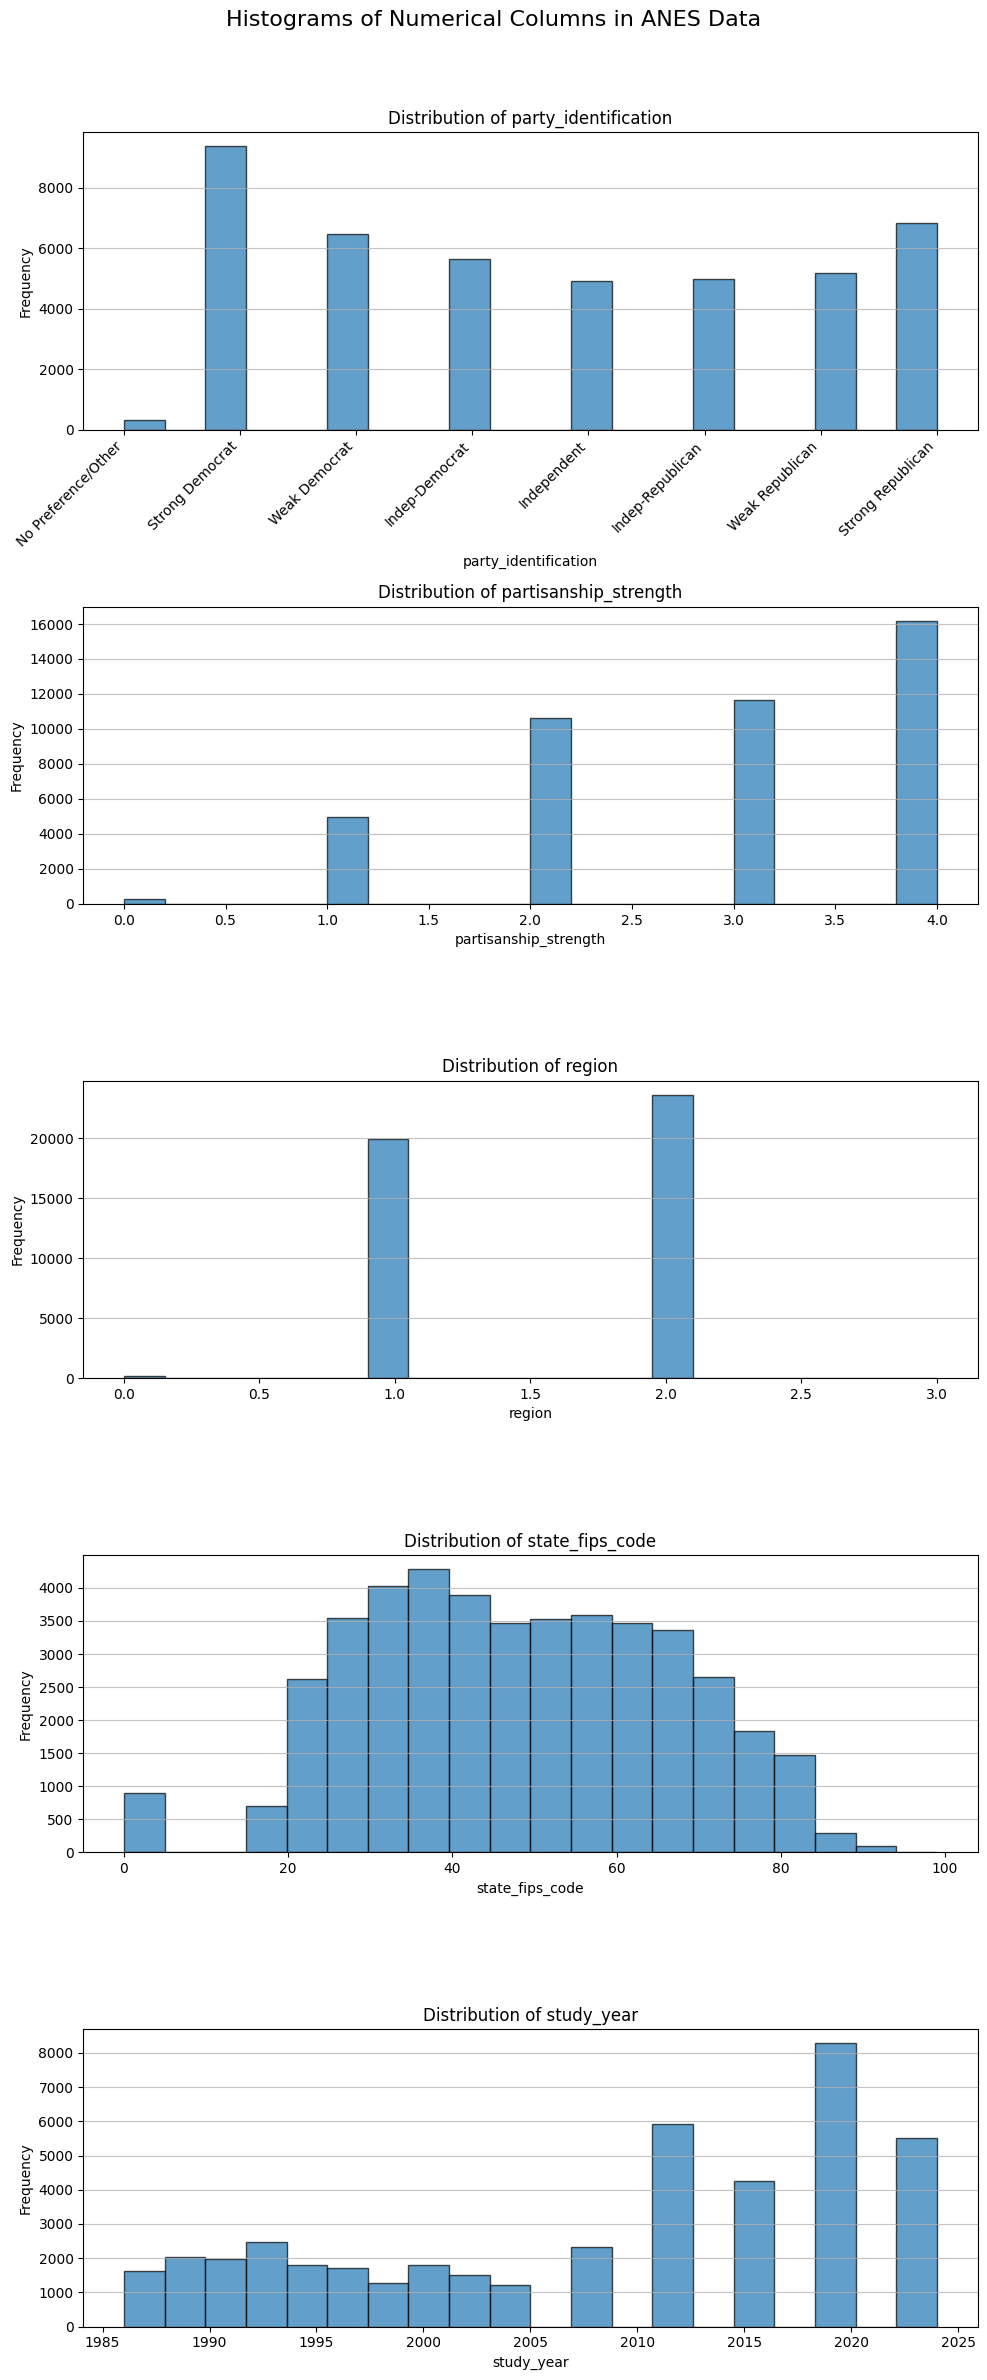

In [ ]:
import matplotlib.pyplot as plt

# Get numerical columns
numerical_cols = DATA_DF.select_dtypes(include=['number']).columns

# Set up the plotting environment
num_plots = len(numerical_cols)
fig, axes = plt.subplots(num_plots, 1, figsize=(10, 5 * num_plots))
fig.suptitle('Histograms of Numerical Columns in ANES Data', fontsize=16)

# Ensure axes is an array even for a single subplot
if num_plots == 1:
    axes = [axes]

# Define the mapping for 'party_identification'
party_id_labels = {
    0: 'No Preference/Other',
    1: 'Strong Democrat',
    2: 'Weak Democrat',
    3: 'Indep-Democrat',
    4: 'Independent',
    5: 'Indep-Republican',
    6: 'Weak Republican',
    7: 'Strong Republican'
}

# Plot histograms for each numerical column
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    ax.hist(DATA_DF[col], bins=20, edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.grid(axis='y', alpha=0.75)

    # Apply custom labels and rotation for 'party_identification'
    if col == 'party_identification':
        # Get unique integer values from the data that are present in the labels map
        unique_values = sorted([val for val in DATA_DF[col].unique() if val in party_id_labels])
        # Get corresponding labels
        labels = [party_id_labels[val] for val in unique_values]

        ax.set_xticks(unique_values)
        ax.set_xticklabels(labels, rotation=45, ha='right') # Rotate labels

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
plt.show()

# Partisanship by state

## Interactions

**Prompt for partisanship by state**

Use DATA_DF to plot a map of the US with a color code for percent demographic. This should be a heatmap with blue for democratic becoming increasingly red as the percentage of replicans increase. An equal percentage of both should be purple.

## Result

In [ ]:
import pandas as pd
import numpy as np
import folium
import us

def categorize_party(party_id):
    if party_id in [1, 2, 3]:
        return 'Democrat'
    elif party_id in [5, 6, 7]:
        return 'Republican'
    elif party_id in [0, 4]:
        return 'Other/Independent'
    else:
        return np.nan

def plot_partisan_map(input_df, us_states_geojson, start_year=None, end_year=None, map_width=700, map_height=400):
    """
    Constructs a choropleth map of US states showing partisan leanings.

    Args:
        input_df (pd.DataFrame): The input DataFrame structured like DATA_DF,
                                 containing 'party_identification', 'state_fips_code',
                                 and 'study_year'.
        us_states_geojson (dict): GeoJSON data for US states.
        start_year (int, optional): The starting year for filtering the data.
        end_year (int, optional): The ending year for filtering the data.
        map_width (int, optional): The width of the generated Folium map in pixels. Defaults to 700.
        map_height (int, optional): The height of the generated Folium map in pixels. Defaults to 400.

    Returns:
        folium.Map: An interactive Folium map displaying partisan leanings.
    """

    filtered_df = input_df.copy()

    # Filter by year if start_year or end_year are provided
    if start_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] >= start_year]
    if end_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] <= end_year]

    # Apply partisan categorization
    filtered_df['partisan_category'] = filtered_df['party_identification'].apply(categorize_party)

    # Calculate partisan proportions per state
    state_partisan_counts = filtered_df.groupby(['state_fips_code', 'partisan_category']).size().unstack(fill_value=0)
    state_partisan_proportions = state_partisan_counts.div(state_partisan_counts.sum(axis=1), axis=0)

    # Ensure 'Republican' and 'Democrat' columns exist, filling with 0 if not present
    for party_col in ['Republican', 'Democrat']:
        if party_col not in state_partisan_proportions.columns:
            state_partisan_proportions[party_col] = 0

    # Calculate partisan lean
    state_partisan_proportions['partisan_lean'] = state_partisan_proportions['Republican'] - state_partisan_proportions['Democrat']

    # Prepare data for Folium (indexing and FIPS/abbr mapping)
    state_partisan_proportions_indexed = state_partisan_proportions.reset_index()
    state_partisan_proportions_indexed['state_fips_code'] = state_partisan_proportions_indexed['state_fips_code'].astype(int).astype(str).str.zfill(2) # Ensure 2-digit FIPS codes

    # Create a mapping from FIPS codes to state abbreviations
    fips_to_abbr = {str(state.fips): state.abbr for state in us.states.STATES + us.states.TERRITORIES}

    # Add a 'state_abbr' column for matching with geojson 'feature.id'
    state_partisan_proportions_indexed['state_abbr'] = state_partisan_proportions_indexed['state_fips_code'].map(fips_to_abbr)

    # Filter out rows where state_abbr is NaN (i.e., FIPS code did not map to a recognized state abbreviation)
    state_partisan_proportions_indexed.dropna(subset=['state_abbr'], inplace=True)

    # Create a Folium map centered on the US, disabling pan and zoom
    m = folium.Map(location=[39.8283, -98.5795], zoom_start=3, scrollWheelZoom=False, dragging=False, width=map_width, height=map_height)

    # Create a linear colormap from blue to purple to red
    blue_to_red = folium.LinearColormap(['blue', 'purple', 'red'], vmin=-1.0, vmax=1.0)

    # Add the choropleth layer to the map
    folium.Choropleth(
        geo_data=us_states_geojson,
        name='Partisan Lean',
        data=state_partisan_proportions_indexed,
        columns=['state_abbr', 'partisan_lean'], # Use 'state_abbr' for matching with 'feature.id'
        key_on='feature.id', # Now this will match 'state_abbr'
        fill_opacity=0.7,
        line_opacity=0.2,
        fill_color='RdBu',
        legend_name='Partisan Lean (Republican - Democrat)',
        bins=[-1, -0.5, -0.25, 0, 0.25, 0.5, 1], # Custom bins to highlight different leanings
        cmap=blue_to_red # This colormap maps negative lean to blue, positive to red
    ).add_to(m)

    # Add a layer control to the map
    folium.LayerControl().add_to(m)

    return m, state_partisan_proportions_indexed

# Example usage of the function:
# Assuming us_states_geojson is already loaded from the previous steps
# us_states_geojson = ... (make sure this variable is available)

# Plot the map for the entire dataset
# map_full_data = plot_partisan_map(DATA_DF, us_states_geojson)
# display(map_full_data)

# Example: Plot the map for data from 1980 onwards
# map_1980_onwards = plot_partisan_map(DATA_DF, us_states_geojson, start_year=1980)
# display(map_1980_onwards)

# Example:
map, indexed = plot_partisan_map(DATA_DF, us_states_geojson, start_year=2000,
                        end_year=2030)
display(map)

NameError: name 'us_states_geojson' is not defined

In [ ]:
import json
import requests

# URL for a GeoJSON file of US states (a common source)
US_STATES_GEOJSON_URL = 'https://raw.githubusercontent.com/python-visualization/folium-example-data/main/us_states.json'

# Fetch the GeoJSON data
response = requests.get(US_STATES_GEOJSON_URL)
us_states_geojson = json.loads(response.text)

print("us_states_geojson has been loaded.")

us_states_geojson has been loaded.


# Partisanship by state over time

## Interactions

**Prompt: Partisanship over time**

Write code to display a sequence of partisanship plots by decade beginning with 1960 through 2020.

**Prompt: Modify partisanship plots**

Create a grid of plots in sequence. Only display the U.S. Disable pan and zoom. Use plot_partisanship_map, but modify it as needed.

**Prompt: Detailed code instruction**
Write a loop that calls plot_partisan_map over the different decades where data are available.

## Hand code

In [ ]:
import pandas as pd
import numpy as np
import folium
import us

def categorize_party(party_id):
    if party_id in [1, 2, 3]:
        return 'Democrat'
    elif party_id in [5, 6, 7]:
        return 'Republican'
    elif party_id in [0, 4]:
        return 'Other/Independent'
    else:
        return np.nan

def plot_partisan_map(input_df, us_states_geojson, start_year=None,
        end_year=None, map_width=700, map_height=400, is_colorbar:bool=True):
    """
    Constructs a choropleth map of US states showing partisan leanings.

    Args:
        input_df (pd.DataFrame): The input DataFrame structured like DATA_DF,
                                 containing 'party_identification', 'state_fips_code',
                                 and 'study_year'.
        us_states_geojson (dict): GeoJSON data for US states.
        start_year (int, optional): The starting year for filtering the data.
        end_year (int, optional): The ending year for filtering the data.
        map_width (int, optional): The width of the generated Folium map in pixels. Defaults to 700.
        map_height (int, optional): The height of the generated Folium map in pixels. Defaults to 400.
        is_colorbar (bool, optional): Whether to include a colorbar. Defaults to True.

    Returns:
        folium.Map: An interactive Folium map displaying partisan leanings.
    """

    filtered_df = input_df.copy()

    # Filter by year if start_year or end_year are provided
    if start_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] >= start_year]
    if end_year is not None:
        filtered_df = filtered_df[filtered_df['study_year'] <= end_year]

    # Apply partisan categorization
    filtered_df['partisan_category'] = filtered_df['party_identification'].apply(categorize_party)

    # Calculate partisan proportions per state
    state_partisan_counts = filtered_df.groupby(['state_fips_code', 'partisan_category']).size().unstack(fill_value=0)
    state_partisan_proportions = state_partisan_counts.div(state_partisan_counts.sum(axis=1), axis=0)

    # Ensure 'Republican' and 'Democrat' columns exist, filling with 0 if not present
    for party_col in ['Republican', 'Democrat']:
        if party_col not in state_partisan_proportions.columns:
            state_partisan_proportions[party_col] = 0

    # Calculate partisan lean
    state_partisan_proportions['partisan_lean'] = state_partisan_proportions['Republican'] - state_partisan_proportions['Democrat']

    # Prepare data for Folium (indexing and FIPS/abbr mapping)
    state_partisan_proportions_indexed = state_partisan_proportions.reset_index()
    state_partisan_proportions_indexed['state_fips_code'] = state_partisan_proportions_indexed['state_fips_code'].astype(int).astype(str).str.zfill(2) # Ensure 2-digit FIPS codes

    # Create a mapping from FIPS codes to state abbreviations
    fips_to_abbr = {str(state.fips): state.abbr for state in us.states.STATES + us.states.TERRITORIES}

    # Add a 'state_abbr' column for matching with geojson 'feature.id'
    state_partisan_proportions_indexed['state_abbr'] = state_partisan_proportions_indexed['state_fips_code'].map(fips_to_abbr)

    # Filter out rows where state_abbr is NaN (i.e., FIPS code did not map to a recognized state abbreviation)
    state_partisan_proportions_indexed.dropna(subset=['state_abbr'], inplace=True)

    # Create a Folium map centered on the US, disabling pan and zoom
    m = folium.Map(location=[39.8283, -98.5795], zoom_start=3, scrollWheelZoom=False, dragging=False, width=map_width, height=map_height)

    # Create a linear colormap from blue to purple to red
    blue_to_red = folium.LinearColormap(['blue', 'purple', 'red'], vmin=-1.0, vmax=1.0)

    # Add the choropleth layer to the map
    choloropath = folium.Choropleth(
        geo_data=us_states_geojson,
        name='Partisan Lean',
        data=state_partisan_proportions_indexed,
        columns=['state_abbr', 'partisan_lean'], # Use 'state_abbr' for matching with 'feature.id'
        key_on='feature.id', # Now this will match 'state_abbr'
        fill_opacity=0.7,
        line_opacity=0.2,
        fill_color='RdBu',
        legend_name='Partisan Lean (Republican - Democrat)',
        bins=[-1, -0.5, -0.25, 0, 0.25, 0.5, 1], # Custom bins to highlight different leanings
        cmap=blue_to_red, # This colormap maps negative lean to blue, positive to red
        show_colorbar=False # Explicitly set to False to hide the colorbar
    ).add_to(m)

    # Remove the colorbar child from the choropleth
    if not is_colorbar:
        for child in list(choloropath._children):
            if child.startswith('color_map'):
                del choloropath._children[child]

    # Add a layer control to the map
    folium.LayerControl().add_to(m)

    return m, state_partisan_proportions_indexed

# Example usage of the function:
# Assuming us_states_geojson is already loaded from the previous steps
# us_states_geojson = ... (make sure this variable is available)

# Plot the map for the entire dataset
# map_full_data = plot_partisan_map(DATA_DF, us_states_geojson)
# display(map_full_data)

# Example: Plot the map for data from 1980 onwards
# map_1980_onwards = plot_partisan_map(DATA_DF, us_states_geojson, start_year=1980)
# display(map_1980_onwards)

# Example:
map, indexed = plot_partisan_map(DATA_DF, us_states_geojson, start_year=2000,
                        end_year=2030)
display(map)

In [ ]:
# Define the decades for which to generate maps
decades = [
    (1960, 1969),
    (1970, 1979),
    (1980, 1989),
    (1990, 1999),
    (2000, 2009),
    (2010, 2019),
    (2020, 2029)
]

print("Decades defined successfully.")

Decades defined successfully.


In [24]:
from IPython.display import HTML

# List to hold HTML representations of each map
maps_html = []

for i, (start_year, end_year) in enumerate(decades):
    # Generate the map for the current decade
    map_decade, _ = plot_partisan_map(DATA_DF, us_states_geojson, start_year=start_year,
            end_year=end_year, map_width=500, map_height=200, is_colorbar=(i==0))

    # Get the HTML representation of the map
    map_html = map_decade._repr_html_()

    # Add a title and the map HTML to the list
    maps_html.append(f"<div style='margin-bottom: 10px;'><h3>Partisan Lean Map for the Decade: {start_year}-{end_year}</h3>{map_html}</div>")

# Combine all map HTMLs into a single string
# Using a flex container to potentially arrange them more compactly, or just stacked
combined_html = "<div style='display: flex; flex-direction: column; gap: 5px;'>" + "".join(maps_html) + "</div>"

# Display the combined HTML
display(HTML(combined_html))

## What we learned

# Tips & Tricks

**Objectives**

* Create correctly running code
* Create a notebook that can be re-run
* Create a "trail" of what you did

**Good Practices**

* Delete unneeded code
* Clearly indicate global variables by naming them in CAPITAL letters
* Write your prompt in the notebook with a title. Have gemini run the prompt by referring to the title.
* Have a clear idea of what you want BEFORE you prompt, and then check the result produced.
* If Gemini is not correctly modifying a function, copy the function into another LLM (e.g., Claude) and ask it to fix the code.
* Change the names of global variables to be meaningful for your purposes. Use Gemini to make sure that the name is changed throughout your notebook.
* Have Gemini create functions and write tests for the functions inside the cell.